# 3. Exploratory Data Analysis

This notebook explores the distribution of 30-day readmission, patient characteristics, healthcare utilization, and encounter-level factors to identify patterns relevant to readmission risk and post-discharge resource prioritization.

## 3.1 Analysis Setup

The processed dataset is loaded for exploratory analysis. A binary target variable is created to distinguish encounters followed by readmission within 30 days from all other encounters.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load processed data
df = pd.read_csv("../data/processed/diabetic_data_mapped.csv")

# Create binary 30-day readmission target
df["readmitted_30d"] = (df["readmitted"] == "<30").astype(int)

# Viridis visual theme
cmap = plt.cm.viridis
colors = cmap(np.linspace(0.15, 0.85, 5))

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11
})

df.shape

(101763, 50)

## 3.2 Target Variable Analysis

The distribution of 30-day readmission is examined to establish the baseline outcome prevalence and assess class imbalance.

In [23]:
target_summary = (
    df["readmitted_30d"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Not Readmitted", 1: "Readmitted <30 Days"})
    .to_frame("Count")
)

target_summary["Percentage"] = (
    target_summary["Count"] / len(df) * 100
).round(2)

target_summary

,Count,Percentage
readmitted_30d,,
Not Readmitted,90406,88.84
Readmitted <30 Days,11357,11.16


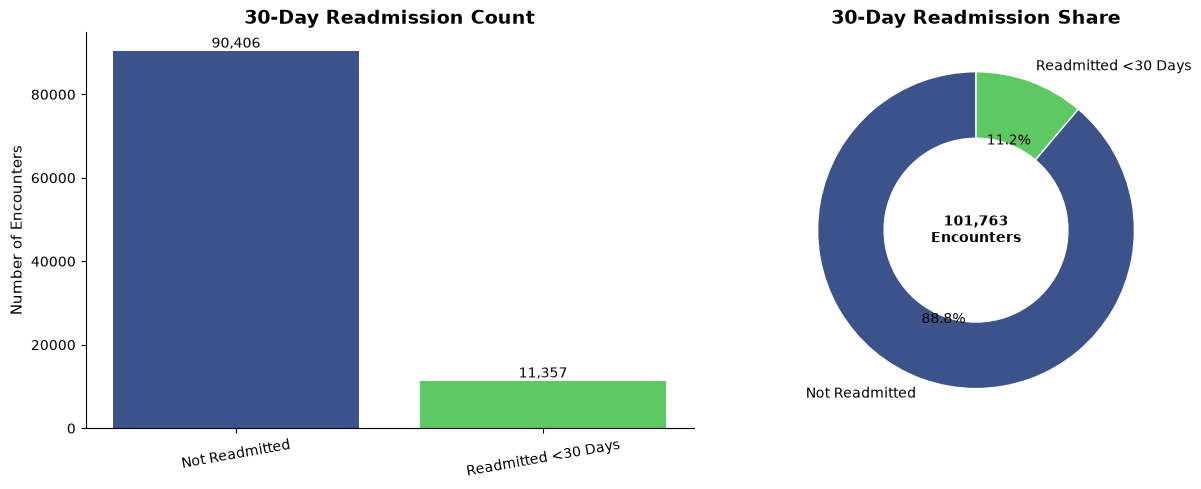

In [24]:
# Target distribution
target_counts = df["readmitted_30d"].value_counts().sort_index()
labels = ["Not Readmitted", "Readmitted <30 Days"]
plot_colors = [cmap(0.25), cmap(0.75)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart — counts
bars = axes[0].bar(
    labels,
    target_counts.values,
    color=plot_colors
)

axes[0].set_title("30-Day Readmission Count")
axes[0].set_ylabel("Number of Encounters")
axes[0].tick_params(axis="x", rotation=10)

# Add count labels
for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

# Donut chart — percentages
axes[1].pie(
    target_counts.values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=plot_colors,
    wedgeprops={"width": 0.42, "edgecolor": "white"}
)

axes[1].text(
    0, 0,
    f"{len(df):,}\nEncounters",
    ha="center",
    va="center",
    fontweight="bold"
)

axes[1].set_title("30-Day Readmission Share")

plt.tight_layout()
plt.show()

Of the 101,763 hospital encounters, 11,357 (11.2%) resulted in readmission within 30 days, while 90,406 (88.8%) did not.

The target variable is therefore imbalanced, with 30-day readmissions representing approximately one in nine encounters. This imbalance should be considered during predictive modeling and model evaluation.

## 3.3 Univariate Analysis

The distributions of selected patient, healthcare utilization, clinical, and encounter characteristics are examined to understand the population represented in the dataset.

### 3.3.1 Patient Characteristics

Age, gender, and race distributions are examined to understand the demographic composition of hospital encounters.

Age distribution

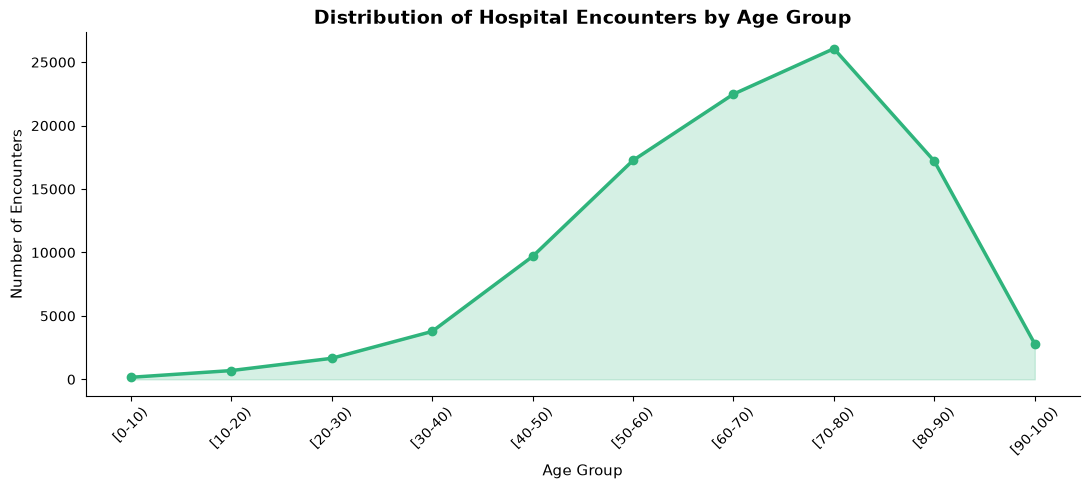

In [25]:
# Define age order
age_order = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"
]

age_counts = (
    df["age"]
    .value_counts()
    .reindex(age_order)
)

# Plot age distribution
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    age_order,
    age_counts.values,
    marker="o",
    linewidth=2.5,
    color=cmap(0.65)
)

ax.fill_between(
    age_order,
    age_counts.values,
    alpha=0.20,
    color=cmap(0.65)
)

ax.set_title("Distribution of Hospital Encounters by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Encounters")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Hospital encounters increase progressively with age and peak among patients aged 70–80 years. Most encounters are concentrated among patients aged 50–90 years, while younger age groups account for relatively few encounters.

Gender and Race Distribution 

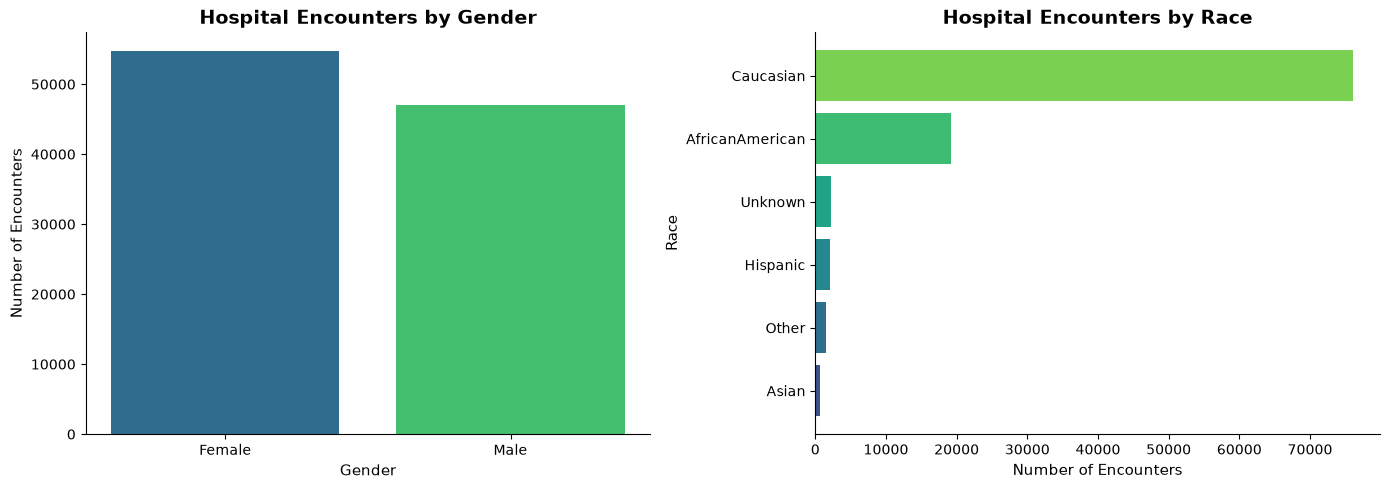

In [26]:
# Prepare distributions
gender_counts = df["gender"].value_counts()
race_counts = df["race"].value_counts().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender — vertical bars
axes[0].bar(
    gender_counts.index,
    gender_counts.values,
    color=[cmap(0.35), cmap(0.70)]
)

axes[0].set_title("Hospital Encounters by Gender")
axes[0].set_ylabel("Number of Encounters")
axes[0].set_xlabel("Gender")

# Race — horizontal bars
race_colors = cmap(np.linspace(0.25, 0.80, len(race_counts)))

axes[1].barh(
    race_counts.index,
    race_counts.values,
    color=race_colors
)

axes[1].set_title("Hospital Encounters by Race")
axes[1].set_xlabel("Number of Encounters")
axes[1].set_ylabel("Race")

plt.tight_layout()
plt.show()

Female encounters slightly exceed male encounters. The racial distribution is predominantly Caucasian, followed by African American patients, while Hispanic, Asian, other, and unknown racial categories represent substantially smaller proportions of encounters.

### 3.3.2 Healthcare Utilization

Prior inpatient, emergency, and outpatient visits are examined to understand patterns of healthcare utilization preceding the current hospital encounter.

In [27]:
utilization_cols = [
    "number_inpatient",
    "number_emergency",
    "number_outpatient"
]

df[utilization_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
number_inpatient,101763.0,0.64,1.26,0.0,0.0,0.0,1.0,21.0
number_emergency,101763.0,0.20,0.93,0.0,0.0,0.0,0.0,76.0
number_outpatient,101763.0,0.37,1.27,0.0,0.0,0.0,0.0,42.0


In [28]:
utilization_summary = pd.DataFrame({
    "No Prior Visits (%)": (df[utilization_cols].eq(0).mean() * 100).round(1),
    "At Least One Prior Visit (%)": (df[utilization_cols].gt(0).mean() * 100).round(1)
})

utilization_summary

,No Prior Visits (%),At Least One Prior Visit (%)
number_inpatient,66.5,33.5
number_emergency,88.8,11.2
number_outpatient,83.6,16.4


Prior healthcare utilization variables are highly right-skewed and concentrated at zero. Therefore, utilization is first summarized as no prior visits versus at least one prior visit to clearly show the prevalence of previous healthcare use. High-utilization values are retained because they may contain meaningful information about readmission risk.

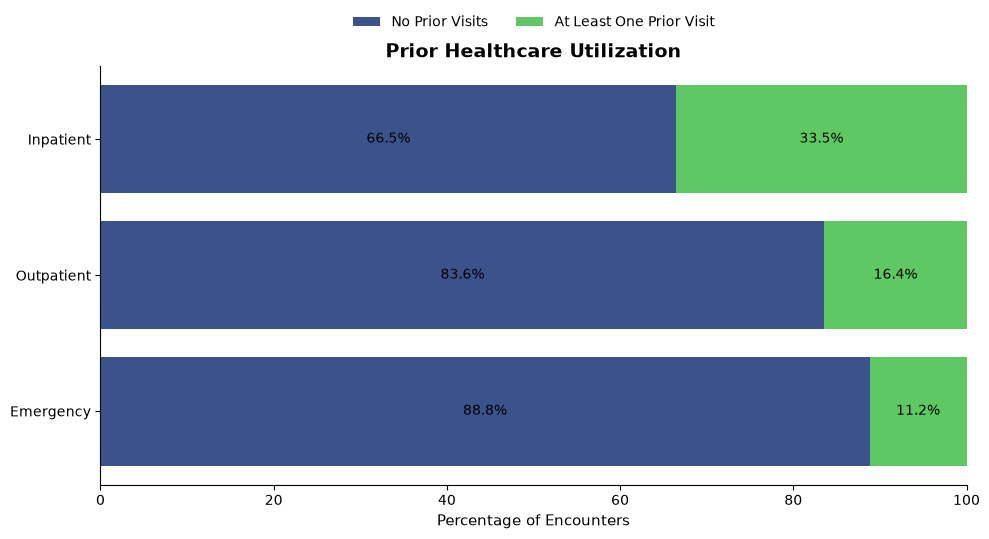

In [29]:
# Prepare data
util_plot = utilization_summary.rename(index={
    "number_inpatient": "Inpatient",
    "number_outpatient": "Outpatient",
    "number_emergency": "Emergency"
}).reindex(["Inpatient", "Outpatient", "Emergency"])

fig, ax = plt.subplots(figsize=(10, 5.5))

# Plot stacked bars
left = np.zeros(len(util_plot))

for col, color in zip(util_plot.columns, [cmap(0.25), cmap(0.75)]):
    values = util_plot[col].values

    ax.barh(
        util_plot.index,
        values,
        left=left,
        color=color,
        label=col.replace(" (%)", "")
    )

    for i, value in enumerate(values):
        ax.text(
            left[i] + value / 2,
            i,
            f"{value:.1f}%",
            ha="center",
            va="center"
        )

    left += values

# Format
ax.set(
    xlim=(0, 100),
    xlabel="Percentage of Encounters",
    ylabel="",
    title="Prior Healthcare Utilization"
)

ax.invert_yaxis()
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.show()

Prior healthcare utilization was limited for most encounters. Prior inpatient use was the most common, with 33.5% of encounters recording at least one inpatient visit, compared with 16.4% for outpatient visits and 11.2% for emergency visits.

This indicates that prior inpatient utilization is more prevalent than prior outpatient or emergency utilization in the study population.

### 3.3.3 Clinical and Encounter Characteristics

Selected encounter and clinical characteristics are examined to understand hospitalization intensity and patient complexity within the study population.

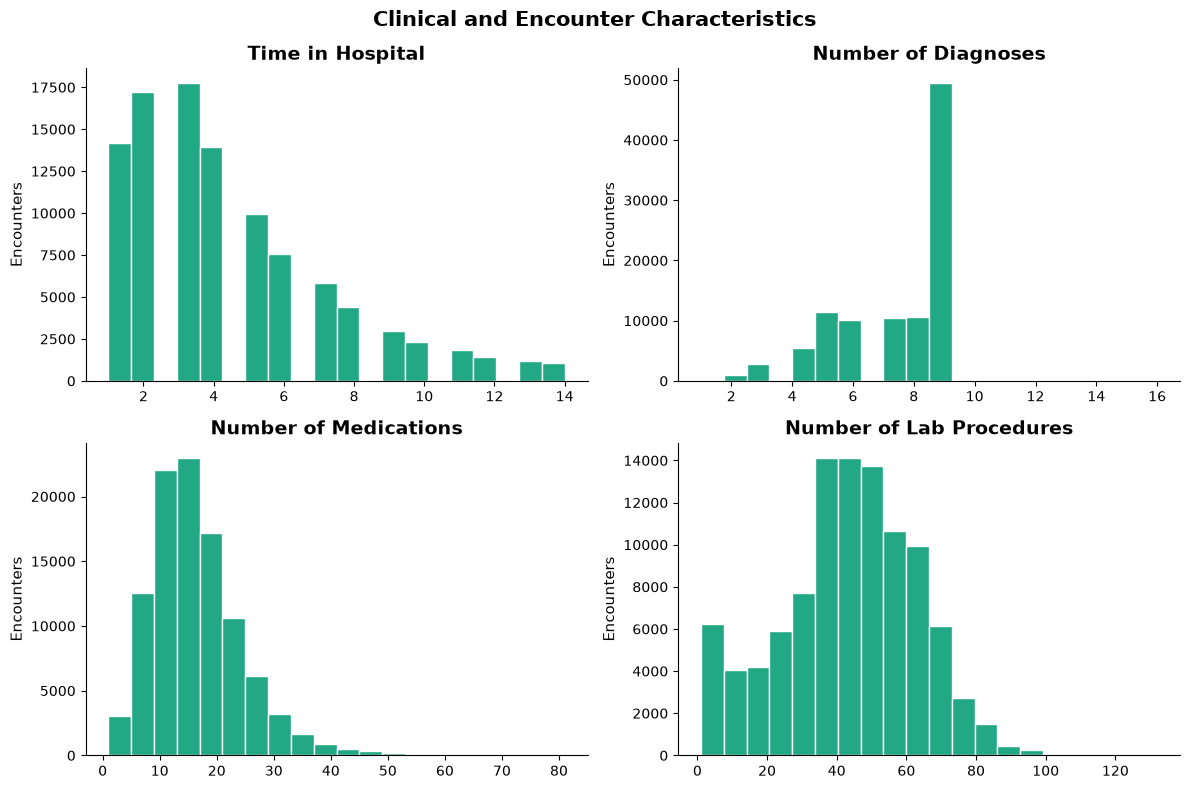

In [30]:
clinical_vars = {
    "time_in_hospital": "Time in Hospital",
    "number_diagnoses": "Number of Diagnoses",
    "num_medications": "Number of Medications",
    "num_lab_procedures": "Number of Lab Procedures"
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (col, title) in zip(axes, clinical_vars.items()):
    ax.hist(
        df[col],
        bins=20,
        color=cmap(0.60),
        edgecolor="white"
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Encounters")

fig.suptitle(
    "Clinical and Encounter Characteristics",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

The clinical and encounter variables show distinct distribution patterns:

- **Time in hospital:** Encounters are concentrated at shorter lengths of stay, particularly within the first few days, with frequency declining as hospitalization duration increases. The distribution is right-skewed, indicating that prolonged hospital stays occur less frequently.

- **Number of diagnoses:** Encounters are concentrated toward the upper end of the recorded diagnosis range, with a pronounced peak around nine diagnoses. This suggests substantial documented clinical complexity among many encounters, although the concentration at nine may also reflect characteristics of how diagnoses were recorded in the dataset.

- **Number of medications:** Most encounters involve moderate medication counts, while progressively fewer encounters involve very large numbers of medications. The right-skewed distribution indicates a smaller subgroup with substantially higher medication burden.

- **Number of laboratory procedures:** Laboratory utilization is more broadly distributed than the other measures, with most encounters concentrated around approximately 30–70 procedures and fewer encounters at very high procedure counts.

Overall, the distributions indicate considerable variation in hospitalization intensity and clinical complexity across encounters. Whether these characteristics are associated with 30-day readmission will be examined in the bivariate analysis.

### 3.3.4 Admission Type

The distribution of admission types is examined to understand the circumstances under which patients entered hospital care.

In [31]:
[col for col in df.columns if "admission" in col.lower()]

['admission_type_id',
 'admission_source_id',
 'admission_type',
 'admission_source']

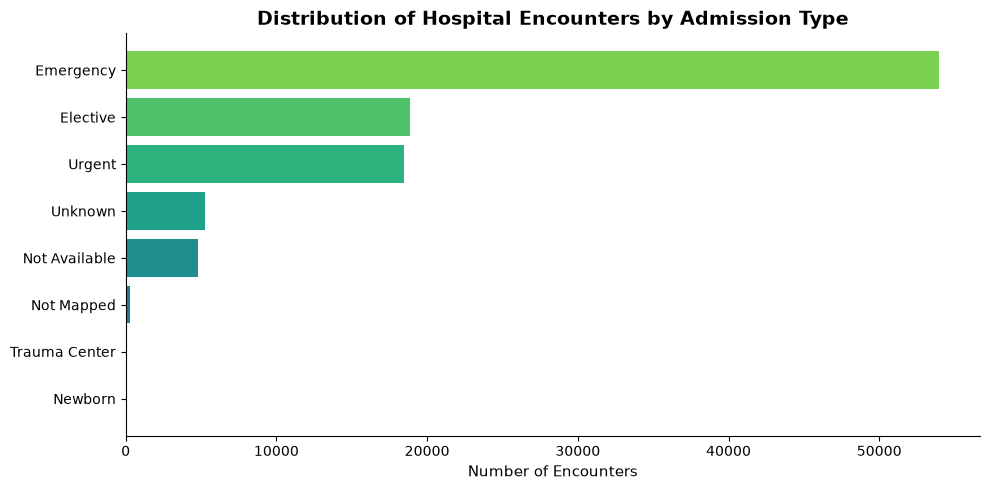

In [32]:
# Admission type distribution
admission_counts = df["admission_type"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    admission_counts.index,
    admission_counts.values,
    color=cmap(np.linspace(0.25, 0.80, len(admission_counts)))
)

ax.set(
    title="Distribution of Hospital Encounters by Admission Type",
    xlabel="Number of Encounters",
    ylabel=""
)

plt.tight_layout()
plt.show()

Emergency admissions dominate the encounter distribution, accounting for substantially more hospital encounters than any other admission type. Elective and urgent admissions form the next largest groups and occur at relatively similar frequencies.

Unknown and unavailable admission types represent a smaller but noticeable proportion of encounters, while admissions classified as not mapped, trauma center, and newborn are rare.

The distribution indicates that hospital encounters in this population are predominantly associated with emergency, urgent, and elective admission pathways. The strong concentration in emergency admissions highlights the largely acute-care nature of the study population.

## 3.4 Bivariate Analysis

Bivariate analysis examines how individual patient, utilization, and clinical characteristics vary with 30-day readmission status. Readmission rates are emphasized rather than raw counts to account for differences in group size.

### 3.4.1 Age and 30-Day Readmission

The relationship between patient age and 30-day readmission is examined by comparing readmission rates across age groups. Rates rather than raw counts are used to account for differences in the number of encounters within each age category.

In [35]:
# binary 30-day readmission indicator
df["readmitted_30"] = (df["readmitted"] == "<30").astype(int)

df["readmitted_30"].value_counts()

readmitted_30
0    90406
1    11357
Name: count, dtype: int64

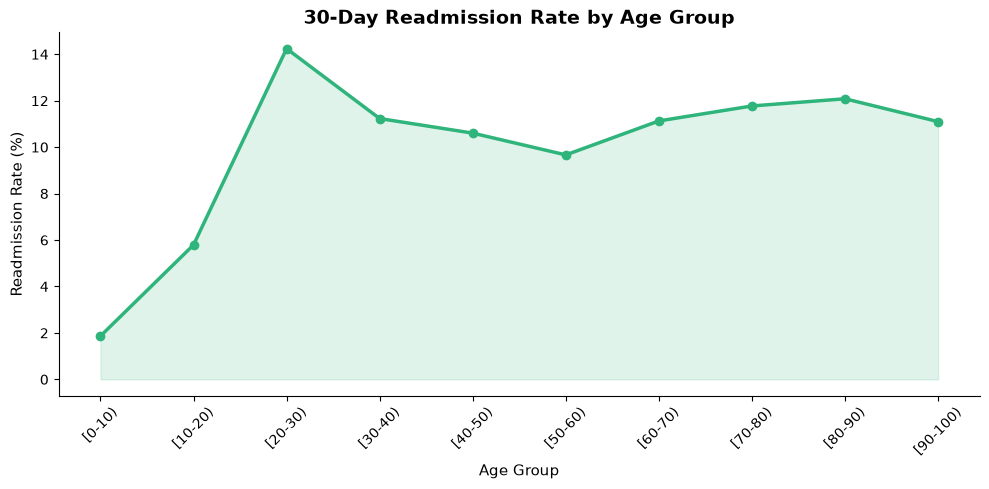

In [36]:
# 30-day readmission rate by age group
age_readmit = (
    df.groupby("age", observed=True)["readmitted_30"]
      .mean()
      .mul(100)
)

age_order = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"
]

age_readmit = age_readmit.reindex(age_order)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    age_readmit.index,
    age_readmit.values,
    marker="o",
    linewidth=2.5,
    color=cmap(0.65)
)

ax.fill_between(
    age_readmit.index,
    age_readmit.values,
    alpha=0.15,
    color=cmap(0.65)
)

ax.set(
    title="30-Day Readmission Rate by Age Group",
    xlabel="Age Group",
    ylabel="Readmission Rate (%)"
)

ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

The relationship between age and 30-day readmission is non-linear. Readmission rates are lowest among patients below 20 years, then rise sharply and peak in the 20–30 age group at approximately 14%.

From age 30 onward, readmission rates remain relatively stable, generally ranging between approximately 10% and 12%. Among older adults, rates increase gradually from the 50–60 through 80–90 age groups before declining slightly among patients aged 90–100.

Age appears to be associated with differences in 30-day readmission rates, although the pattern does not show a simple continuous increase with advancing age. The unusually high rate among patients aged 20–30 should also be interpreted alongside the smaller number of encounters in younger age groups.

### 3.4.2 Gender and 30-Day Readmission

The 30-day readmission rate is compared across gender groups to determine whether readmission patterns differ between male and female patients.

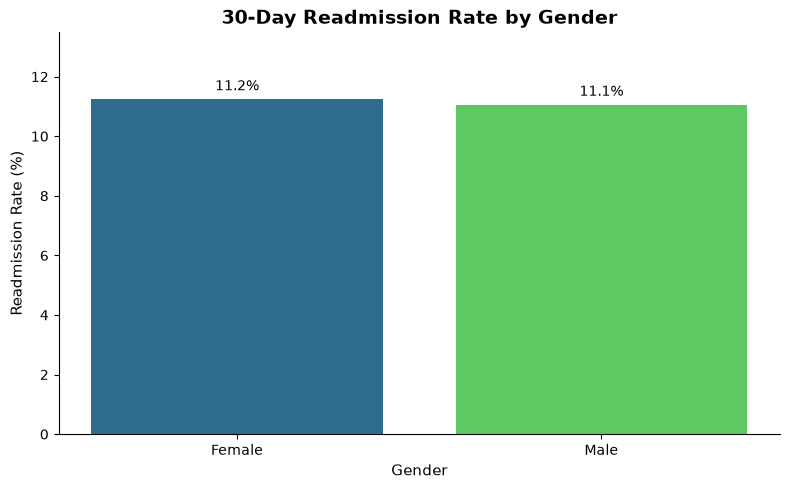

In [37]:
# 30-day readmission rate by gender
gender_readmit = (
    df.groupby("gender")["readmitted_30"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    gender_readmit.index,
    gender_readmit.values,
    color=cmap(np.linspace(0.35, 0.75, len(gender_readmit)))
)

ax.bar_label(
    bars,
    labels=[f"{v:.1f}%" for v in gender_readmit.values],
    padding=4
)

ax.set(
    title="30-Day Readmission Rate by Gender",
    xlabel="Gender",
    ylabel="Readmission Rate (%)"
)

ax.set_ylim(0, gender_readmit.max() * 1.2)

plt.tight_layout()
plt.show()

The 30-day readmission rate is nearly identical across gender groups, at approximately 11.2% for females and 11.1% for males. The difference of only about 0.1 percentage points indicates little observable variation in readmission rates by gender.

Based on this descriptive comparison, gender does not appear to meaningfully differentiate 30-day readmission risk in this dataset. Its predictive contribution will be evaluated further during multivariate analysis and model development.

### 3.4.3 Race and 30-Day Readmission

The 30-day readmission rate is compared across racial groups to examine whether readmission patterns vary across the demographic categories represented in the dataset.

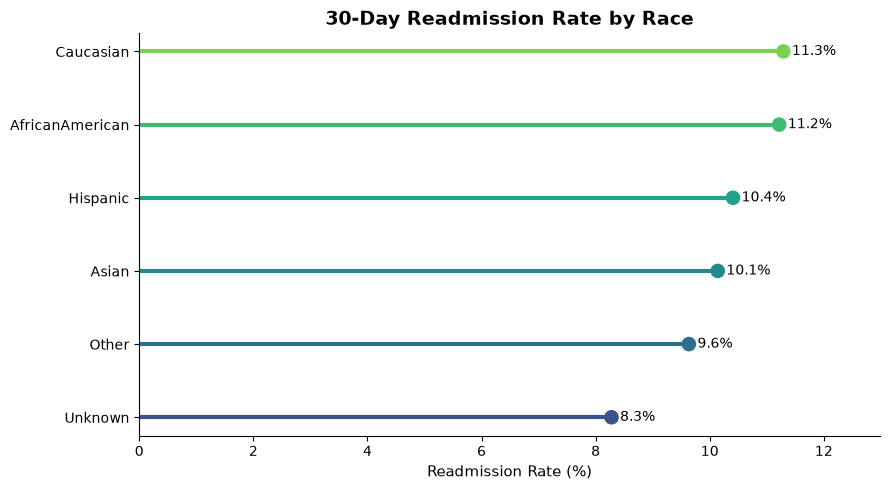

In [38]:
# 30-day readmission rate by race
race_readmit = (
    df.groupby("race")["readmitted_30"]
      .mean()
      .mul(100)
      .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 5))

colors = cmap(np.linspace(0.25, 0.80, len(race_readmit)))

ax.hlines(
    y=race_readmit.index,
    xmin=0,
    xmax=race_readmit.values,
    color=colors,
    linewidth=3
)

ax.scatter(
    race_readmit.values,
    race_readmit.index,
    c=colors,
    s=90
)

# Percentage labels
for i, value in enumerate(race_readmit.values):
    ax.text(
        value + 0.15,
        i,
        f"{value:.1f}%",
        va="center"
    )

ax.set(
    title="30-Day Readmission Rate by Race",
    xlabel="Readmission Rate (%)",
    ylabel=""
)

ax.set_xlim(0, race_readmit.max() * 1.15)

plt.tight_layout()
plt.show()

Thirty-day readmission rates vary moderately across racial groups. Caucasian and African American patients, which represent the largest racial groups in the dataset, have nearly identical readmission rates of 11.3% and 11.2%, respectively.

Hispanic and Asian patients show slightly lower rates of 10.4% and 10.1%, while patients classified as Other have a readmission rate of 9.6%. The Unknown race category records the lowest rate at 8.3%.

The observed differences across the major racial groups are relatively modest, particularly between Caucasian and African American patients. Rates for smaller racial categories should be interpreted cautiously because their lower encounter counts may produce less stable estimates. Further multivariate analysis will help determine whether race contributes meaningful information after accounting for other patient and clinical characteristics.

### 3.4.4 Prior Healthcare Utilization and 30-Day Readmission

The relationship between previous healthcare utilization and 30-day readmission is examined across prior inpatient, emergency, and outpatient visits. Each utilization measure is grouped into no prior visits versus at least one prior visit to provide a clear comparison of readmission rates.

In [39]:
# Compare readmission rates by prior utilization
util_cols = {
    "number_inpatient": "Inpatient",
    "number_emergency": "Emergency",
    "number_outpatient": "Outpatient"
}

records = []

for col, label in util_cols.items():
    rates = df.groupby(df[col].gt(0))["readmitted_30"].mean() * 100

    records.append([
        label,
        rates.get(False, 0),
        rates.get(True, 0)
    ])

util_readmit = pd.DataFrame(
    records,
    columns=["Utilization", "No Prior Visits", "At Least One Prior Visit"]
).set_index("Utilization")

util_readmit

,No Prior Visits,At Least One Prior Visit
Utilization,,
Inpatient,8.437458,16.554371
Emergency,10.474663,16.603707
Outpatient,10.674633,13.626859


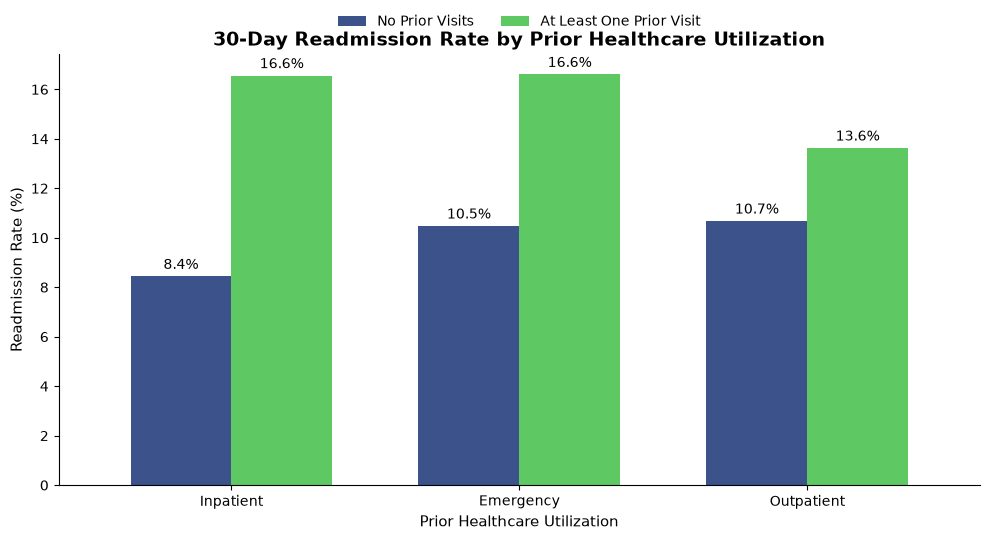

In [40]:
# Plot prior utilization vs 30-day readmission
ax = util_readmit.plot(
    kind="bar",
    figsize=(10, 5.5),
    color=[cmap(0.25), cmap(0.75)],
    width=0.7
)

# Percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

ax.set(
    title="30-Day Readmission Rate by Prior Healthcare Utilization",
    xlabel="Prior Healthcare Utilization",
    ylabel="Readmission Rate (%)"
)

ax.legend(
    title="",
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=2
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Prior healthcare utilization is associated with higher observed 30-day readmission rates across all three utilization settings.

The strongest difference is observed for prior inpatient utilization. Encounters with at least one prior inpatient visit have a 30-day readmission rate of 16.6%, compared with 8.4% among those with no prior inpatient visits—an increase of approximately 8.1 percentage points and nearly twice the observed rate.

Prior emergency utilization shows a similar pattern, with readmission increasing from 10.5% among patients with no prior emergency visits to 16.6% among those with at least one. The difference for outpatient utilization is smaller but remains noticeable, increasing from 10.7% to 13.6%.

Overall, prior inpatient and emergency utilization show stronger separation in 30-day readmission rates than prior outpatient utilization. These findings suggest that recent patterns of healthcare use may provide important information for identifying patients at greater risk of readmission, although their independent contribution will need to be evaluated in multivariate analysis.

### 3.4.5 Admission Type and 30-Day Readmission

The relationship between admission type and 30-day readmission is examined by comparing readmission rates across the different admission pathways. Rates are used rather than raw counts because the number of encounters varies substantially across admission categories.

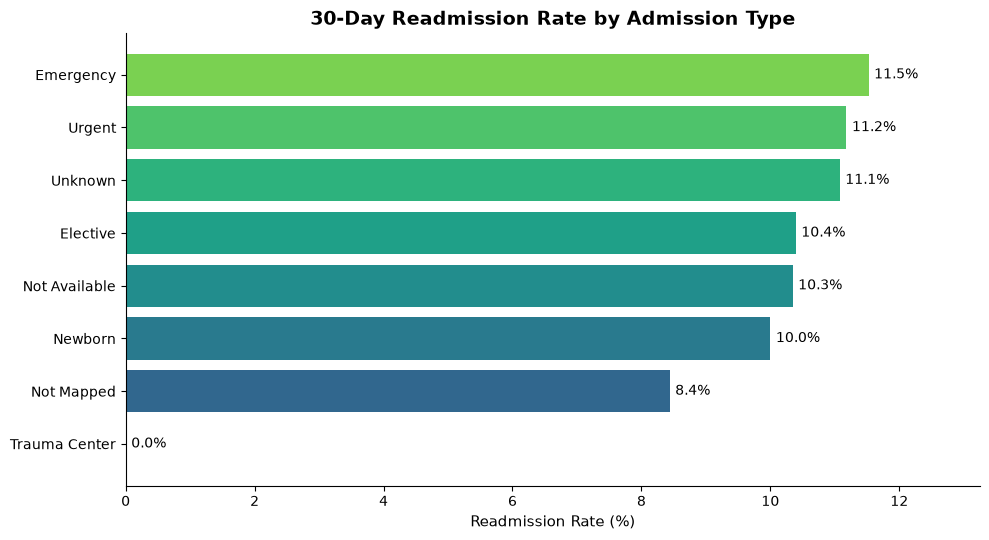

In [41]:
# 30-day readmission rate by admission type
admission_readmit = (
    df.groupby("admission_type")["readmitted_30"]
      .mean()
      .mul(100)
      .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 5.5))

colors = cmap(np.linspace(0.25, 0.80, len(admission_readmit)))

bars = ax.barh(
    admission_readmit.index,
    admission_readmit.values,
    color=colors
)

ax.bar_label(
    bars,
    labels=[f"{v:.1f}%" for v in admission_readmit.values],
    padding=4
)

ax.set(
    title="30-Day Readmission Rate by Admission Type",
    xlabel="Readmission Rate (%)",
    ylabel=""
)

ax.set_xlim(0, admission_readmit.max() * 1.15)

plt.tight_layout()
plt.show()

Thirty-day readmission rates vary moderately across admission types. Emergency admissions have the highest rate among the major admission categories at 11.5%, followed closely by urgent admissions at 11.2%. Elective admissions have a somewhat lower readmission rate of 10.4%.

Encounters with an unknown admission type show a readmission rate of 11.1%, while those classified as Not Available have a rate of 10.3%. The differences among the major admission pathways are therefore relatively small, with only about a one percentage-point separation between emergency and elective admissions.

The 0.0% rate for Trauma Center admissions and the 10.0% rate for Newborn admissions should not be interpreted as stable patterns because these categories contain very few encounters. Overall, admission type shows some variation in 30-day readmission, but the descriptive separation is considerably weaker than that observed for prior healthcare utilization.

### 3.4.6 Clinical and Encounter Characteristics and 30-Day Readmission

The relationship between selected clinical and encounter characteristics and 30-day readmission is examined to determine whether readmission rates vary with hospitalization intensity and clinical complexity. The analysis focuses on length of stay, number of diagnoses, medication burden, and laboratory procedures.

In [42]:
clinical_cols = [
    "time_in_hospital",
    "number_diagnoses",
    "num_medications",
    "num_lab_procedures"
]

clinical_summary = (
    df.groupby("readmitted_30")[clinical_cols]
      .mean()
      .T
      .rename(columns={
          0: "Not Readmitted",
          1: "Readmitted <30 Days"
      })
      .round(2)
)

clinical_summary

readmitted_30,Not Readmitted,Readmitted <30 Days
time_in_hospital,4.35,4.77
number_diagnoses,7.39,7.69
num_medications,15.91,16.90
num_lab_procedures,42.95,44.23


### 3.4.6.1 Length of Stay and Number of Diagnoses

Readmission rates are examined across length of hospital stay and number of recorded diagnoses to assess whether greater encounter duration and clinical complexity are associated with changes in 30-day readmission.

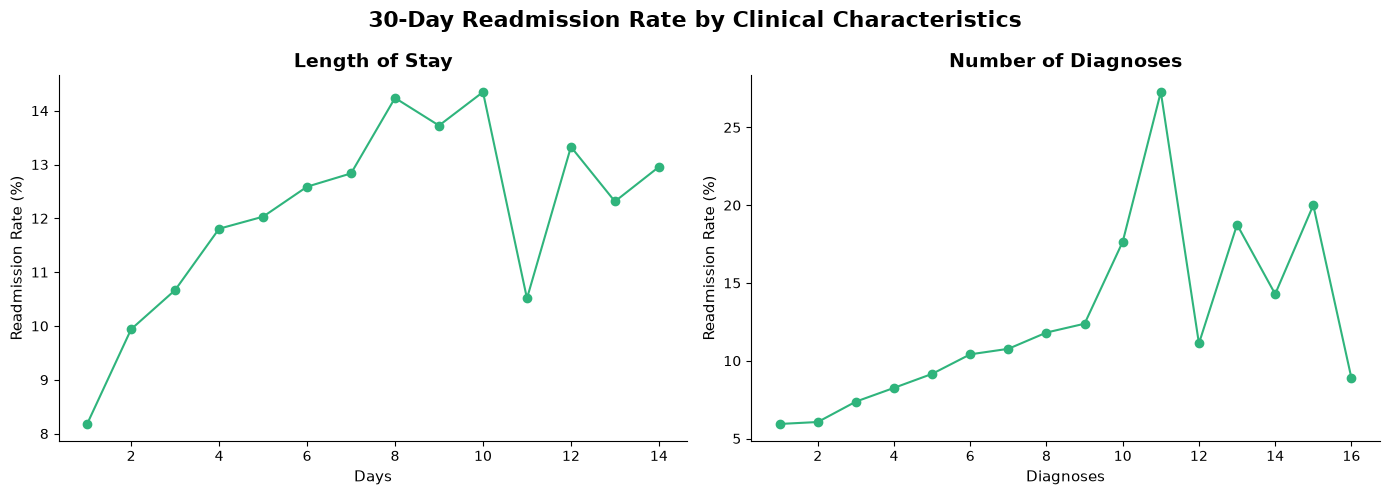

In [43]:
# Readmission rates by length of stay and diagnoses
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

variables = {
    "time_in_hospital": ("Length of Stay", "Days"),
    "number_diagnoses": ("Number of Diagnoses", "Diagnoses")
}

for ax, (col, (title, xlabel)) in zip(axes, variables.items()):
    rates = df.groupby(col)["readmitted_30"].mean().mul(100)

    ax.plot(
        rates.index,
        rates.values,
        marker="o",
        color=cmap(0.65)
    )

    ax.set(
        title=title,
        xlabel=xlabel,
        ylabel="Readmission Rate (%)"
    )

fig.suptitle(
    "30-Day Readmission Rate by Clinical Characteristics",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Thirty-day readmission rates generally increase with length of hospital stay. The rate rises from approximately 8.2% for one-day stays to around 12–13% for stays of four to seven days, reaching above 14% for some longer stays. Although some fluctuations occur after ten days, the pattern suggests that longer hospitalizations are associated with higher observed readmission rates.

A similar relationship is evident for the number of diagnoses across the more commonly observed range. Readmission rates increase progressively from approximately 6% among encounters with one or two diagnoses to more than 12% among those with nine diagnoses.

The sharp fluctuations observed beyond approximately ten diagnoses should be interpreted cautiously. These less common diagnosis counts may contain relatively few encounters, making their readmission-rate estimates less stable.

These patterns suggest that greater hospitalization intensity and clinical complexity may be associated with increased 30-day readmission risk. Length of stay and diagnosis burden therefore warrant further evaluation during multivariate analysis and predictive modeling.

### 3.4.6.2 Medication and Laboratory Procedure Burden

Medication and laboratory procedure counts are grouped into clinically interpretable ranges to examine how 30-day readmission rates vary with increasing treatment and diagnostic intensity. Grouping also reduces instability caused by relatively uncommon extreme values.

In [44]:
# Create medication and laboratory procedure groups
df["med_group"] = pd.cut(
    df["num_medications"],
    bins=[0, 10, 20, 30, 40, np.inf],
    labels=["1–10", "11–20", "21–30", "31–40", "40+"]
)

df["lab_group"] = pd.cut(
    df["num_lab_procedures"],
    bins=[-1, 20, 40, 60, 80, np.inf],
    labels=["0–20", "21–40", "41–60", "61–80", "80+"]
)

med_rate = (
    df.groupby("med_group", observed=True)["readmitted_30"]
      .mean()
      .mul(100)
)

lab_rate = (
    df.groupby("lab_group", observed=True)["readmitted_30"]
      .mean()
      .mul(100)
)

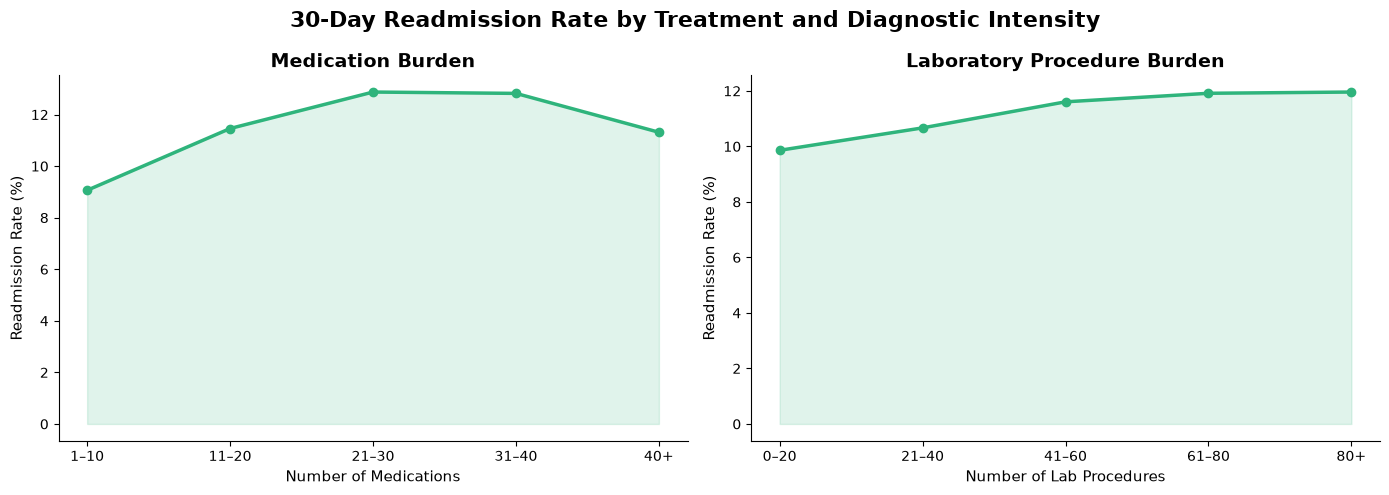

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, rates, title, xlabel in [
    (axes[0], med_rate, "Medication Burden", "Number of Medications"),
    (axes[1], lab_rate, "Laboratory Procedure Burden", "Number of Lab Procedures")
]:
    ax.plot(
        rates.index.astype(str),
        rates.values,
        marker="o",
        linewidth=2.5,
        color=cmap(0.65)
    )

    ax.fill_between(
        rates.index.astype(str),
        rates.values,
        alpha=0.15,
        color=cmap(0.65)
    )

    ax.set(
        title=title,
        xlabel=xlabel,
        ylabel="Readmission Rate (%)"
    )

fig.suptitle(
    "30-Day Readmission Rate by Treatment and Diagnostic Intensity",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Medication burden shows a clear increase in 30-day readmission rates across the lower and moderate medication groups. The rate rises from approximately 9% among encounters involving 1–10 medications to about 11.5% for 11–20 medications, reaching approximately 13% among patients receiving 21–30 medications.

The rate remains relatively stable for the 31–40 medication group before declining to approximately 11.3% among encounters involving more than 40 medications. This indicates a non-linear relationship, with the highest observed readmission rates occurring among patients with moderate-to-high medication burden rather than the most extreme medication group.

Laboratory procedure burden shows a more gradual pattern. Readmission rates increase from approximately 9.9% among encounters with 0–20 laboratory procedures to nearly 12% among those with 61–80 procedures. Beyond this level, the rate largely plateaus, with little additional increase among encounters involving more than 80 procedures.

These patterns suggest that greater treatment and diagnostic intensity is associated with higher observed 30-day readmission rates, although neither relationship is strictly linear. Medication burden appears to provide stronger differentiation across groups than laboratory procedure burden.

### 3.4.7 Diabetes-Related Clinical Indicators and 30-Day Readmission

Diabetes-related clinical indicators are examined to assess whether glycemic testing, diabetes medication use, and changes in medication are associated with differences in 30-day readmission rates. The analysis focuses on A1C results, maximum serum glucose results, diabetes medication status, and medication changes.

In [46]:
# Diabetes-related indicators
diabetes_vars = [
    "A1Cresult",
    "max_glu_serum",
    "diabetesMed",
    "change"
]

diabetes_rates = {
    col: df.groupby(col)["readmitted_30"].mean().mul(100).sort_values()
    for col in diabetes_vars
}

for col, rates in diabetes_rates.items():
    print(f"\n{col}")
    print(rates.round(1))


A1Cresult
A1Cresult
Norm           9.7
>8             9.9
>7            10.0
Not Tested    11.4
Name: readmitted_30, dtype: float64

max_glu_serum
max_glu_serum
Not Tested    11.1
Norm          11.4
>200          12.5
>300          14.3
Name: readmitted_30, dtype: float64

diabetesMed
diabetesMed
No      9.6
Yes    11.6
Name: readmitted_30, dtype: float64

change
change
No    10.6
Ch    11.8
Name: readmitted_30, dtype: float64


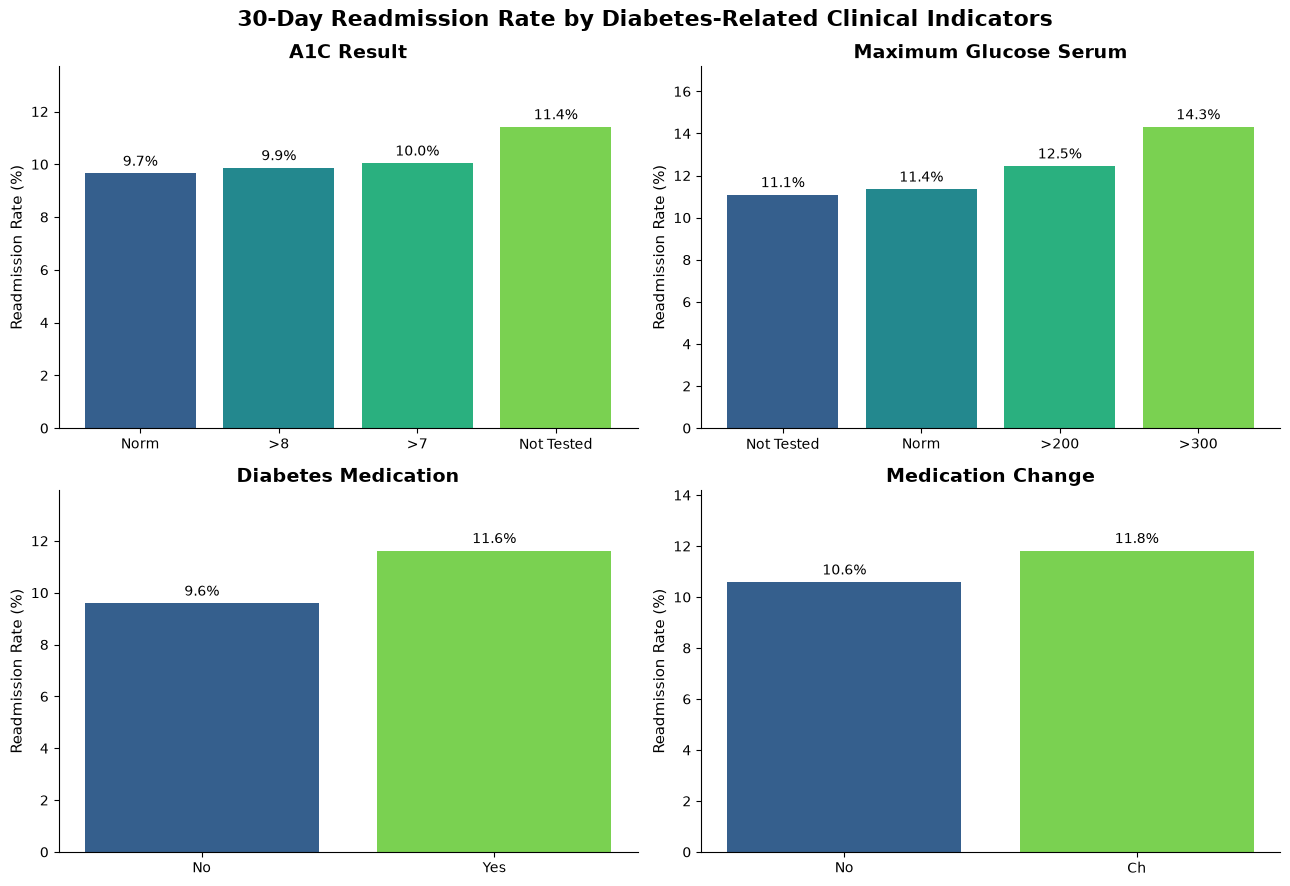

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

titles = {
    "A1Cresult": "A1C Result",
    "max_glu_serum": "Maximum Glucose Serum",
    "diabetesMed": "Diabetes Medication",
    "change": "Medication Change"
}

for ax, col in zip(axes.flat, diabetes_vars):
    rates = diabetes_rates[col]
    colors = cmap(np.linspace(0.30, 0.80, len(rates)))

    bars = ax.bar(
        rates.index.astype(str),
        rates.values,
        color=colors
    )

    ax.bar_label(
        bars,
        labels=[f"{v:.1f}%" for v in rates.values],
        padding=3
    )

    ax.set(
        title=titles[col],
        xlabel="",
        ylabel="Readmission Rate (%)"
    )

    ax.set_ylim(0, rates.max() * 1.2)

fig.suptitle(
    "30-Day Readmission Rate by Diabetes-Related Clinical Indicators",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

The diabetes-related indicators show varying relationships with 30-day readmission.

A1C results show relatively small differences among patients who were tested. Readmission rates range from 9.7% for normal A1C results to approximately 10.0% for elevated results. Patients classified as Not Tested have a higher observed readmission rate of 11.4%. This suggests that A1C level itself does not show a clear increasing relationship with readmission in this descriptive analysis.

Maximum serum glucose shows a clearer gradient. Readmission increases from 11.4% among patients with normal results to 12.5% for glucose levels above 200 and 14.3% for levels above 300. This pattern suggests that markedly elevated glucose measurements may be associated with greater 30-day readmission risk.

Patients receiving diabetes medication have a higher readmission rate than those not receiving diabetes medication (11.6% versus 9.6%). Similarly, encounters involving a medication change have a slightly higher readmission rate than those without a change (11.8% versus 10.6%).

These findings indicate that severe glucose elevation and diabetes treatment-related characteristics may help differentiate readmission risk. The associations with diabetes medication and medication changes should be interpreted cautiously, however, because they may also reflect greater underlying disease severity rather than an effect of treatment itself.

### 3.4.8 Insulin Status and 30-Day Readmission

Insulin treatment status is examined to determine whether 30-day readmission rates differ between patients with no insulin use, stable insulin therapy, and those whose insulin dosage was increased or decreased during the encounter.

In [49]:
# Readmission rate and encounter count by insulin status
insulin_summary = (
    df.groupby("insulin")["readmitted_30"]
      .agg(["mean", "count"])
)

insulin_summary["Readmission Rate (%)"] = insulin_summary["mean"] * 100

insulin_summary[
    ["count", "Readmission Rate (%)"]
].round(1)

,count,Readmission Rate (%)
insulin,,
Down,12218,13.9
No,47380,10.0
Steady,30849,11.1
Up,11316,13.0


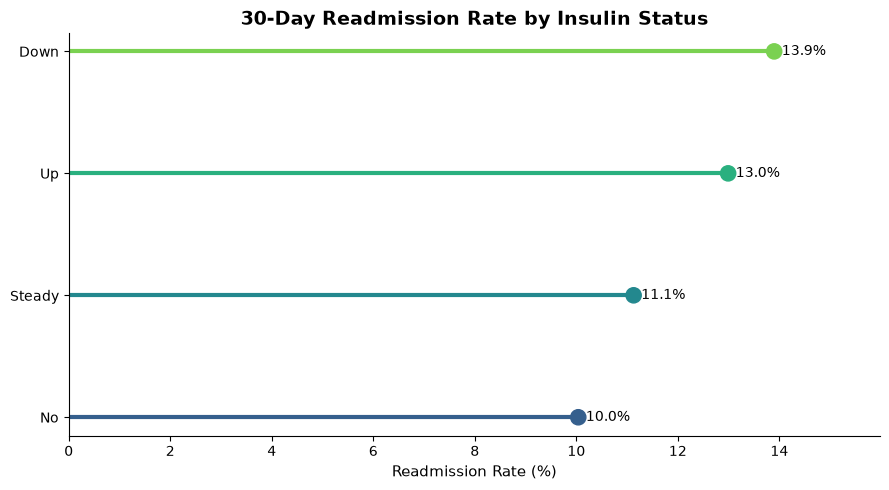

In [50]:
# Prepare insulin rates
insulin_rate = (
    insulin_summary["Readmission Rate (%)"]
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 5))

colors = cmap(np.linspace(0.30, 0.80, len(insulin_rate)))

ax.hlines(
    y=insulin_rate.index,
    xmin=0,
    xmax=insulin_rate.values,
    color=colors,
    linewidth=3
)

ax.scatter(
    insulin_rate.values,
    insulin_rate.index,
    c=colors,
    s=120
)

for i, value in enumerate(insulin_rate.values):
    ax.text(
        value + 0.15,
        i,
        f"{value:.1f}%",
        va="center"
    )

ax.set(
    title="30-Day Readmission Rate by Insulin Status",
    xlabel="Readmission Rate (%)",
    ylabel=""
)

ax.set_xlim(0, insulin_rate.max() * 1.15)

plt.tight_layout()
plt.show()

Thirty-day readmission rates differ across insulin treatment categories. Patients with no recorded insulin use have the lowest readmission rate at 10.0%, while those maintained on a steady insulin regimen have a slightly higher rate of 11.1%.

Higher readmission rates are observed among patients whose insulin dosage was adjusted. Patients with an increased insulin dosage have a readmission rate of 13.0%, while those with a decreased dosage have the highest rate at 13.9%. This represents a difference of approximately 3.9 percentage points between patients with decreased insulin dosage and those with no insulin use.

The pattern suggests that insulin adjustment may help identify encounters involving greater clinical complexity or instability. The association should not be interpreted as evidence that changing insulin dosage causes readmission, since treatment adjustments may instead reflect underlying disease severity or difficulties in glycemic management.

Insulin status therefore appears to provide useful discriminatory information for 30-day readmission and warrants further evaluation alongside other clinical variables in multivariate analysis.